In [1]:
# Import or install Sionna
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2,3"

import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import plotly.graph_objects as go

no_preview = False # Toggle to False to use the preview widget

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver
from sionna.rt.utils import r_hat

2026-02-24 14:19:57.774298: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 14:19:57.813849: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 14:19:58.719166: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# ==============================================================================
# 1. XML 파일 경로 보정 및 로드
# ==============================================================================
# 원본 파일 경로 (사용자 환경에 맞게 설정)
xml_path = "/data/hw/sionna/ws/scenes/kookmin/kookmin_fixed.xml"
scene_dir = os.path.dirname(xml_path)
temp_xml_path = os.path.join(scene_dir, "kookmin_tmp.xml") # 임시 수정 파일

# 1) 원본 XML 읽기
with open(xml_path, 'r', encoding='utf-8') as f:
    xml_content = f.read()

# 2) 상대 경로("meshes/")를 절대 경로로 치환하여 "파일 찾기 실패" 방지
#    (예: "meshes/file.ply" -> "/data1/mh/.../meshes/file.ply")
abs_mesh_path = os.path.join(scene_dir, "meshes") + "/"
xml_content_fixed = xml_content.replace('value="meshes/', f'value="{abs_mesh_path}')

# 3) 수정된 내용을 임시 파일로 저장
with open(temp_xml_path, 'w', encoding='utf-8') as f:
    f.write(xml_content_fixed)

print(f"[준비] 경로가 수정된 임시 XML 파일을 생성했습니다: {temp_xml_path}")

# 4) 장면 로드
try:
    scene = load_scene(temp_xml_path, merge_shapes=False)
    print("[성공] 장면(Scene)을 성공적으로 불러왔습니다.")
except Exception as e:
    print(f"[오류] 장면 로드 실패: {e}")

# ==============================================================================
# 2. 재질(Material) 정보 확인
# ==============================================================================
if 'scene' in globals():
    print("\n" + "="*60)
    print(f"{'Object Name':<30} | {'Assigned Material':<20}")
    print("="*60)
    
    # 씬에 있는 모든 객체를 순회하며 할당된 재질 확인
    for name, obj in scene.objects.items():
        # 재질 객체가 있으면 이름 출력, 없으면 None
        mat_name = obj.radio_material.name if obj.radio_material else "None"
        print(f"{name:<30} | {mat_name:<20}")
        
    print("="*60)
    
    # 정의된 모든 재질(Radio Material) 목록 확인
    print("\n[정의된 재질 목록]")
    for mat_name, mat in scene.radio_materials.items():
        print(f" - 이름: {mat_name:<15} (Type: {mat.itu_type}, Thickness: {mat.thickness})")

[준비] 경로가 수정된 임시 XML 파일을 생성했습니다: /data/hw/sionna/ws/scenes/kookmin/kookmin_tmp.xml
[성공] 장면(Scene)을 성공적으로 불러왔습니다.

Object Name                    | Assigned Material   
elm__2                         | itu                 
elm__3                         | itu                 
elm__5                         | itu                 
elm__7                         | itu                 
elm__9                         | itu                 

[정의된 재질 목록]
 - 이름: itu             (Type: concrete, Thickness: [0.2])


In [3]:
# ==============================================================================
# 2. 도로 재질 변경 (시각화용)
# ==============================================================================
red_road_mat = ITURadioMaterial(name="red_road_mat_7",
                                itu_type="concrete",
                                thickness=0.2,
                                color=[1.0, 0.0, 0.0])
scene.add(red_road_mat)

road_object_id = "elm__7"
if road_object_id in scene.objects:
    scene.objects[road_object_id].radio_material = red_road_mat
    print(f"[설정] 도로({road_object_id})를 빨간색으로 변경했습니다.")

[설정] 도로(elm__7)를 빨간색으로 변경했습니다.


In [4]:
road_positions = []

print(f"[탐색] Mitsuba Scene 내부에서 '{road_object_id}' 형상을 찾습니다...")

if hasattr(scene, 'mi_scene'):
    mi_scene = scene.mi_scene
    
    # 1. Mitsuba Scene의 모든 Shape를 순회하며 ID 매칭
    target_shape = None
    for s in mi_scene.shapes():
        if s.id() == road_object_id:
            target_shape = s
            break
    
    if target_shape: 
        try:           
            params = mi.traverse(target_shape)
                        
            if 'vertex_positions' in params:
                vertex_buffer = params['vertex_positions']
                
                # NumPy 변환 (1차원 배열: x, y, z, x, y, z ...)
                vertices_flat = np.array(vertex_buffer)
                
                # (N, 3) 형태로 변환 (x, y, z)
                if len(vertices_flat) > 0:
                    vertices = vertices_flat.reshape(-1, 3)
                    road_positions = vertices
                    print(f"  -> 추출된 도로 좌표 수: {len(road_positions)}개")
                else:
                    print("  [경고] 버퍼가 비어있습니다.")
            else:
                print(f"[오류] '{road_object_id}' 객체에 'vertex_positions' 속성이 없습니다.")

        except Exception as e:
            print(f"[오류] Vertex 추출 중 에러 발생: {e}")
    else:
        print(f"[실패] ID가 '{road_object_id}'인 Shape를 mi_scene에서 찾을 수 없습니다.")
else:
    print("[오류] scene 객체에서 'mi_scene' 속성을 찾을 수 없습니다.")

[탐색] Mitsuba Scene 내부에서 'elm__7' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 226개


In [5]:
x_vals = road_positions[:, 0]
z_vals = road_positions[:, 2] 
indices = list(range(len(road_positions)))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_vals, y=z_vals,
    mode='markers',
    marker=dict(size=5, color='blue'),
    text=indices,
    hovertemplate='<b>Index: %{text}</b><br>X: %{x:.1f}<br>Z: %{y:.1f}<extra></extra>' # 라벨도 Z로 표기
))

fig.update_layout(
    title="도로 점 확인용 지도 (X - Z 평면)",
    xaxis_title="X Axis (East/West)",
    yaxis_title="y Axis (North/South)", # Y축 라벨을 Z축으로 변경
    width=1000, height=800,
    hovermode='closest'
)

fig.show()

In [6]:
# 1. 설정 및 초기화
target_pos = road_positions[0]
print("="*60 + f"\n[설정] 테스트 목표: {target_pos}\n" + "="*60)

# 기존 객체 제거
for name in ['Tx_1', 'Tx_2', 'Tx_3', 'Car_Marker']:
    if name in scene.transmitters: scene.remove(name)
if 'rx_car' in scene.receivers: scene.remove('rx_car')

rx = Receiver(name="rx_car", position=target_pos)
rx.receive_antenna = scene.rx_array
scene.add(rx)
print(" -> 자동차(Rx) 배치 완료.")

cam = Camera(position=target_pos + np.array([0, 100, 100]), look_at=target_pos)
print("[시각화] 3D 뷰어 실행")
scene.preview(show_devices=True, point_picker=True)

[설정] 테스트 목표: [-190.90263    0.3     -138.76404]
 -> 자동차(Rx) 배치 완료.
[시각화] 3D 뷰어 실행


In [7]:
# 1. 설정 및 초기화
target_pos = road_positions[0]
print("="*60 + f"\n[설정] 테스트 목표: {target_pos}\n" + "="*60)

# 2. 장치 배치
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")

tx_positions = [[-12.176, 25, 84.599]]#, [323.472, 36.869, -204.315], [0.663, 56.367, -181.453]]
tx_names = ["Tx_1"]#, "Tx_2", "Tx_3"]

# 기존 객체 제거
for name in tx_names + ['Car_Marker']:
    if name in scene.transmitters: scene.remove(name)
if 'rx_car' in scene.receivers: scene.remove('rx_car')

for i, pos in enumerate(tx_positions):
    tx = Transmitter(name=tx_names[i], position=pos, power_dbm=43)
    tx.transmit_antenna = scene.tx_array
    tx.look_at(target_pos)
    scene.add(tx)
    print(f" -> {tx_names[i]} 배치 완료.")

rx = Receiver(name="rx_car", position=target_pos)
rx.receive_antenna = scene.rx_array
scene.add(rx)
print(" -> 자동차(Rx) 배치 완료.")

# 3. 시뮬레이션
print("[연산] 경로 계산 시작...")
solver = PathSolver()
paths = solver(scene, max_depth=5, samples_per_src=1000000, diffuse_reflection=True, diffraction=True)

# 4. 결과 검증
a, tau = paths.cir()
if tf.size(a) > 0 and tf.reduce_sum(tf.abs(a)) > 0:
    print(f"\n✅ [성공] 전파 도달 (Amp Sum: {tf.reduce_sum(tf.abs(a)):.2e})")
else:
    print("\n❌ [실패] 전파 미도달 (장애물 또는 거리 문제)")

# 5. 시각화
cam = Camera(position=target_pos + np.array([0, 100, 100]), look_at=target_pos)
print("[시각화] 3D 뷰어 실행")
scene.preview(paths=paths, show_devices=True)

[설정] 테스트 목표: [-190.90263    0.3     -138.76404]
 -> Tx_1 배치 완료.
 -> 자동차(Rx) 배치 완료.
[연산] 경로 계산 시작...


2026-02-24 14:20:00.195545: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21745 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6
2026-02-24 14:20:00.196892: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22190 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:68:00.0, compute capability: 8.6



❌ [실패] 전파 미도달 (장애물 또는 거리 문제)
[시각화] 3D 뷰어 실행


In [8]:
# ==============================================================================
# 0. 데이터 준비 & 이동 경로 계산
# ==============================================================================
if 'road_positions' not in globals():
    raise ValueError("❌ 'road_positions' 데이터가 없습니다.")

path_indices = [205, 203, 201, 199, 197, 195, 193, 190, 182, 183, 7, 5]
waypoints = road_positions[path_indices].copy()
waypoints[:, 1] += 1.5

# 한글 주석: 기준 속도(30 km/h -> m/s)
speed_ms = 90.0 / 3.6
delta_t = 0.5

# 한글 주석: 구간 거리/누적 거리 계산
diffs = waypoints[1:] - waypoints[:-1]
segment_dists = np.linalg.norm(diffs, axis=1)
cumulative_dists = np.concatenate(([0], np.cumsum(segment_dists)))
total_distance = cumulative_dists[-1]
total_time = total_distance / speed_ms if speed_ms > 0 else 0.0
time_steps = np.arange(0, total_time + delta_t, delta_t)

def get_state_at_time(t):
    """
    한글 주석: 시각 t에서 차량 위치(pos)와 속도벡터(vel)를 반환
    """
    if len(waypoints) < 2:
        return waypoints[0], np.array([0.0, 0.0, 0.0], dtype=np.float32)

    target_dist = np.clip(speed_ms * t, 0.0, total_distance)
    idx = np.searchsorted(cumulative_dists, target_dist) - 1
    idx = max(0, min(idx, len(waypoints) - 2))

    seg_start = cumulative_dists[idx]
    seg_len = segment_dists[idx]

    if seg_len <= 1e-9:
        return waypoints[idx], np.array([0.0, 0.0, 0.0], dtype=np.float32)

    ratio = (target_dist - seg_start) / seg_len
    pos = waypoints[idx] + ratio * (waypoints[idx+1] - waypoints[idx])

    # 한글 주석: 진행 방향 단위벡터 * 속도크기 = 속도벡터
    direction = (waypoints[idx+1] - waypoints[idx]) / seg_len
    vel = direction * speed_ms
    return pos, vel

# 기존 코드 호환용
def get_pos_at_time(t):
    pos, _ = get_state_at_time(t)
    return pos

# ==============================================================================
# 1. 씬(Scene) 초기화
# ==============================================================================
if hasattr(scene, 'transmitters'):
    for name in list(scene.transmitters.keys()):
        scene.remove(name)
if hasattr(scene, 'receivers'):
    for name in list(scene.receivers.keys()):
        scene.remove(name)

scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")

# 한글 주석: tx_positions, tx_names가 이전 셀에 없으면 기본값 사용
if "tx_positions" not in globals():
    tx_positions = [[-12.176, 25.0, 84.599]]
if "tx_names" not in globals():
    tx_names = ["Tx_1"]

for i, pos in enumerate(tx_positions):
    tx = Transmitter(
        name=tx_names[i],
        position=pos,
        power_dbm=43,
        velocity=[0.0, 0.0, 0.0]  # 한글 주석: 송신기는 정지 가정
    )
    tx.transmit_antenna = scene.tx_array
    tx.look_at([0, 0, 0])
    scene.add(tx)

start_pos, start_vel = get_state_at_time(0.0)
rx = Receiver(
    name="rx_car",
    position=start_pos,
    velocity=start_vel  # 한글 주석: 초기 속도 설정
)
rx.receive_antenna = scene.rx_array
scene.add(rx)

solver = PathSolver()

# ==============================================================================
# 2. 인터랙티브 위젯
# ==============================================================================
output_widget = widgets.Output()

def update_simulation(frame_idx):
    t = float(time_steps[frame_idx])
    current_pos, current_vel = get_state_at_time(t)

    # 한글 주석: 위치/속도 업데이트 (도플러 반영 핵심)
    rx.position = current_pos
    rx.velocity = current_vel
    for name in tx_names:
        scene.transmitters[name].look_at(current_pos)

    paths = solver(
        scene,
        max_depth=3,
        max_num_paths_per_src=100000,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    with output_widget:
        output_widget.clear_output(wait=True)

        scene.preview(paths=paths, show_devices=True, resolution=[800, 600])

        # 한글 주석: 단일 시각 전력 표시
        a0, _ = paths.cir(out_type="tf", normalize_delays=False)
        p_val = tf.reduce_sum(tf.abs(a0)**2) if tf.size(a0) > 0 else 0.0
        db_val = 10*np.log10(float(p_val) + 1e-30)

        print(f"⏱ Time: {t:.1f}s | 📍 Pos: {current_pos} | 🚗 Vel: {current_vel} m/s | 📶 Power: {db_val:.2f} dB")

slider = widgets.IntSlider(
    value=0, min=0, max=len(time_steps)-1, step=1,
    description='Time Step:', layout=widgets.Layout(width='600px')
)

widgets.interactive_output(update_simulation, {'frame_idx': slider})

print("▼ 슬라이더를 움직여보세요.")
display(slider, output_widget)


▼ 슬라이더를 움직여보세요.


IntSlider(value=0, description='Time Step:', layout=Layout(width='600px'), max=24)

Output()

CIR 측정

In [9]:
frame_idx = 0  # 보고 싶은 프레임 인덱스(원하는 값으로 바꿔)
t = time_steps[frame_idx]
current_pos = get_pos_at_time(t)

# 위치/방향 업데이트
rx.position = current_pos
for name in tx_names:
    scene.transmitters[name].look_at(current_pos)

# 경로 계산
paths = solver(scene, max_depth=3, samples_per_src=100000,
               diffuse_reflection=True, diffraction=True,synthetic_array=True)

# CIR 추출
a, tau = paths.cir(out_type="tf", normalize_delays=False)

print("t =", t)
print("a shape:", a.shape)
print("tau shape:", tau.shape)

t = 0.0
a shape: (1, 2, 1, 2, 47, 1)
tau shape: (1, 1, 47)


In [10]:
# 계산 결과 캐시: (frame_idx, tx_idx, rel_delay) -> (t, pos, df)
_pdp_cache = {}

out = widgets.Output()

tx_dropdown = widgets.Dropdown(
    options=[("Tx_1", 0)],#, ("Tx_2", 1), ("Tx_3", 2)],
    value=0,
    description="TX:",
    layout=widgets.Layout(width="200px")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps)-1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

# 0부터 시작하는 상대지연으로 볼지 옵션 (원하면 켜기)
rel_delay_chk = widgets.Checkbox(
    value=False,
    description="Relative delay (min τ = 0)",
    indent=False
)

def _compute_mapping_for_frame(frame_idx: int, tx_idx: int, rel_delay: bool):
    key = (frame_idx, tx_idx, rel_delay)
    if key in _pdp_cache:
        return _pdp_cache[key]

    t = float(time_steps[frame_idx])
    pos = get_pos_at_time(t)

    # 위치/방향 업데이트
    rx.position = pos
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    # 경로 계산
    paths = solver(
        scene,
        max_depth=3,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    # CIR 추출 (절대 지연)
    a, tau = paths.cir(out_type="tf", normalize_delays=False)

    # 너 케이스 기준:
    # a: (1, 2, 3, 128, P, 1)
    # tau: (1, 3, P)
    tau_tx = tau[0, tx_idx, :]  

    # PDP: Rx편파(2) + Tx포트(128) 합산 -> (P,)
    pdp = tf.reduce_sum(tf.abs(a[0, :, tx_idx, :, :, 0])**2, axis=[0, 1])  # (P,)

    # ---------------------------
    # padding/가짜 경로 제거
    #   - tau가 음수(-1 같은)면 padding일 가능성이 큼
    # ---------------------------
    valid = tf.math.is_finite(tau_tx) & (tau_tx >= 0)
    idx_valid = tf.where(valid)[:, 0]  # (P_valid,)

    if tf.size(idx_valid) == 0:
        # 유효 경로 없음
        df = pd.DataFrame(columns=["path_idx", "tau_ns", "pdp_db"])
        _pdp_cache[key] = (t, pos, df)
        return _pdp_cache[key]

    tau_v = tf.boolean_mask(tau_tx, valid)   # (P_valid,)
    pdp_v = tf.boolean_mask(pdp, valid)      # (P_valid,)

    # 상대지연 옵션: min τ를 0으로 이동
    if rel_delay:
        tau_v = tau_v - tf.reduce_min(tau_v)

    # 지연 기준 정렬
    order = tf.argsort(tau_v)
    tau_s = tf.gather(tau_v, order).numpy() * 1e9  # ns
    pdp_s = tf.gather(pdp_v, order).numpy()
    pdp_db = 10*np.log10(pdp_s + 1e-30)

    # 정렬된 path_idx (원래 인덱스 기준)
    path_idx_sorted = tf.gather(idx_valid, order).numpy()


    df = pd.DataFrame({
        "path_idx": path_idx_sorted.astype(int),
        "tau_ns": tau_s,
        "pdp_db": pdp_db
        })

    _pdp_cache[key] = (t, pos, df)
    return _pdp_cache[key]

def _update_plot(_=None):
    frame_idx = frame_slider.value
    tx_idx = tx_dropdown.value
    rel_delay = rel_delay_chk.value

    with out:
        out.clear_output(wait=True)

        t, pos, df = _compute_mapping_for_frame(frame_idx, tx_idx, rel_delay)

        if df.empty:
            print(f"t={t:.2f}s | frame={frame_idx} | Tx_{tx_idx+1} : 유효 경로가 없습니다 (완전 차폐/패딩 제거 후 0개).")
            print(f"pos={pos}")
            return

        # 1) 매핑 테이블 출력 (path_idx ↔ 임펄스)
        display(df)

        # 2) CIR(PDP) stem + 라벨(path_idx)
        plt.figure(figsize=(8, 3.6))
        plt.stem(df["tau_ns"].values, df["pdp_db"].values, basefmt=" ")

        # 라벨: 각 임펄스 위에 path_idx
        for x, y, pid in zip(df["tau_ns"].values, df["pdp_db"].values, df["path_idx"].values):
            plt.text(x, y, str(pid), fontsize=9, ha="center", va="bottom")

        plt.xlabel("Delay τ (ns)")
        plt.ylabel("Power (dB)")
        plt.title(f"Tx_{tx_idx+1} PDP at t={t:.2f}s | frame={frame_idx}\npos={pos}")
        plt.grid(True)
        plt.show()

# 이벤트 연결
frame_slider.observe(_update_plot, names="value")
tx_dropdown.observe(_update_plot, names="value")
rel_delay_chk.observe(_update_plot, names="value")

display(widgets.VBox([widgets.HBox([frame_slider, tx_dropdown]), rel_delay_chk]), out)
_update_plot()

Output()

In [11]:
frame_idx = 0  # 보고 싶은 프레임 인덱스(원하는 값으로 바꿔)
t = time_steps[frame_idx]
current_pos = get_pos_at_time(t)

# 위치/방향 업데이트
rx.position = current_pos
for name in tx_names:
    scene.transmitters[name].look_at(current_pos)

# 경로 계산
paths = solver(scene, max_depth=3, samples_per_src=100000,
               diffuse_reflection=True, diffraction=True,synthetic_array=True)

# 한글 주석: taps 설정값
bandwidth = 20e6          # 채널 대역폭 [Hz]
l_min, l_max = 0, 50     # 탭 인덱스 범위
sampling_frequency = 1000.0          # 시간축 샘플링 주파수 [Hz]
num_time_steps = 16       # 시간 샘플 수(도플러 반영)

# 한글 주석: taps 계산 (복소수 TF 텐서 반환)
h_taps = paths.taps(
    bandwidth=bandwidth,
    l_min=l_min,
    l_max=l_max,
    sampling_frequency=sampling_frequency,
    num_time_steps=num_time_steps,
    normalize=False,
    normalize_delays=False,
    out_type="tf"
)

print("h_taps shape:", h_taps.shape)  # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_taps]
print("num_taps:", l_max - l_min + 1)

# 한글 주석: 첫 링크/안테나의 시간-탭 전력(dB) 예시
# synthetic_array=True, 1x1 배열이면 보통 [0,0,0,0,:,:]로 접근 가능
h00 = h_taps[0, 0, 0, 0, :, :]                     # [T, L]
p00 = tf.abs(h00)**2
p00_db = 10.0 * tf.math.log(p00 + 1e-30) / tf.math.log(10.0)

print("h00 shape [T,L]:", h00.shape)
print("power[dB] min/max:", tf.reduce_min(p00_db).numpy(), tf.reduce_max(p00_db).numpy())

# 한글 주석: 특정 시간 인덱스의 탭 벡터 확인
t_idx = 0
print(f"t_idx={t_idx}, tap power(dB):")
print(p00_db[t_idx].numpy())

h_taps shape: (1, 2, 1, 2, 16, 51)
num_taps: 51
h00 shape [T,L]: (16, 51)
power[dB] min/max: -142.79842 -85.65818
t_idx=0, tap power(dB):
[-119.04761  -118.04985  -116.91481  -115.598885 -114.033775 -112.103615
 -109.58632  -105.96372   -99.41123   -86.42276  -100.40346  -106.43864
 -110.538666 -113.11286  -115.15407  -117.18545  -118.97229  -110.09516
 -128.16156  -119.61921  -120.934456 -122.09163  -122.97554  -123.833435
 -124.64792  -125.437836 -126.22162  -127.020996 -127.86705  -128.81236
 -129.96742  -131.63138  -135.09796  -141.15565  -116.61528  -125.825615
 -128.41148  -130.00911  -131.41096  -132.85048  -134.4808   -137.11363
 -139.89331  -140.3145   -133.88628  -126.00584  -114.50604  -110.64298
 -119.41675  -122.80891  -124.824104]


In [12]:
# 한글 주석: 캐시 (frame_idx, tx_idx, rel_delay) -> (t, pos, df)
_taps_cache = {}

out = widgets.Output()

tx_dropdown = widgets.Dropdown(
    options=[(name, i) for i, name in enumerate(tx_names)],
    value=0,
    description="TX:",
    layout=widgets.Layout(width="220px")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps)-1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

rel_delay_chk = widgets.Checkbox(
    value=False,
    description="Relative delay (min τ = 0)",
    indent=False
)

def _compute_taps_for_frame(frame_idx: int, tx_idx: int, rel_delay: bool):
    key = (frame_idx, tx_idx, rel_delay)
    if key in _taps_cache:
        return _taps_cache[key]

    t = float(time_steps[frame_idx])
    pos = get_pos_at_time(t)

    # 한글 주석: Rx 위치/방향 갱신
    rx.position = pos
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    # 한글 주석: 경로 계산
    paths = solver(
        scene,
        max_depth=3,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    # 한글 주석: taps 계산 (TF 텐서)
    h = paths.taps(
        bandwidth=bandwidth,
        l_min=l_min,
        l_max=l_max,
        sampling_frequency=sampling_frequency,
        num_time_steps=num_time_steps,
        normalize=False,
        normalize_delays=False,
        out_type="tf"
    )
    # 기대 shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_taps]

    # 한글 주석: Rx=0, 선택 Tx, time=0에서 안테나 축 합산해 PDP 생성
    h_sel = h[0, :, tx_idx, :, 0, :]                         # [num_rx_ant, num_tx_ant, num_taps]
    pdp = tf.reduce_sum(tf.abs(h_sel)**2, axis=[0, 1])       # [num_taps]
    pdp_np = pdp.numpy()

    tap_idx = np.arange(l_min, l_max + 1, dtype=int)
    tau_ns = (tap_idx / bandwidth) * 1e9                     # τ = l / W

    valid = np.isfinite(pdp_np) & (pdp_np > 0)
    if np.sum(valid) == 0:
        df = pd.DataFrame(columns=["tap_idx", "tau_ns", "pdp_db"])
        _taps_cache[key] = (t, pos, df)
        return _taps_cache[key]

    tap_v = tap_idx[valid]
    tau_v = tau_ns[valid]
    pdp_v = pdp_np[valid]

    if rel_delay:
        tau_v = tau_v - np.min(tau_v)

    order = np.argsort(tau_v)
    tap_s = tap_v[order]
    tau_s = tau_v[order]
    pdp_db = 10*np.log10(pdp_v[order] + 1e-30)

    df = pd.DataFrame({
        "tap_idx": tap_s.astype(int),
        "tau_ns": tau_s,
        "pdp_db": pdp_db
    })

    _taps_cache[key] = (t, pos, df)
    return _taps_cache[key]

def _update_plot(_=None):
    frame_idx = frame_slider.value
    tx_idx = tx_dropdown.value
    rel_delay = rel_delay_chk.value

    with out:
        out.clear_output(wait=True)

        t, pos, df = _compute_taps_for_frame(frame_idx, tx_idx, rel_delay)

        if df.empty:
            print(f"t={t:.2f}s | frame={frame_idx} | {tx_names[tx_idx]} : 유효 탭이 없습니다.")
            print(f"pos={pos}")
            return

        # 한글 주석: 테이블 출력
        display(df)

        # 한글 주석: taps 기반 PDP stem
        plt.figure(figsize=(8, 3.6))
        plt.stem(df["tau_ns"].values, df["pdp_db"].values, basefmt=" ")
        for x, y, tap in zip(df["tau_ns"].values, df["pdp_db"].values, df["tap_idx"].values):
            plt.text(x, y, str(tap), fontsize=9, ha="center", va="bottom")

        plt.xlabel("Delay τ (ns)")
        plt.ylabel("Power (dB)")
        plt.title(f"{tx_names[tx_idx]} taps-PDP at t={t:.2f}s | frame={frame_idx}\npos={pos}")
        plt.grid(True)
        plt.show()

# 한글 주석: 위젯 이벤트 연결
frame_slider.observe(_update_plot, names="value")
tx_dropdown.observe(_update_plot, names="value")
rel_delay_chk.observe(_update_plot, names="value")

display(widgets.VBox([widgets.HBox([frame_slider, tx_dropdown]), rel_delay_chk]), out)
_update_plot()


Output()

In [13]:
from sionna.rt.constants import InteractionType, INVALID_SHAPE

C = 299_792_458.0  # m/s

TYPE_NAME = {
    int(InteractionType.NONE): "None",
    int(InteractionType.SPECULAR): "Specular",
    int(InteractionType.DIFFUSE): "Diffuse",
    int(InteractionType.REFRACTION): "Refraction",
    int(InteractionType.DIFFRACTION): "Diffraction",
}

def paths_debug_table(paths, scene, tx_idx: int):
    syn = bool(getattr(paths, "synthetic_array", True))

    if syn:
        inter = paths.interactions.numpy()[:, 0, tx_idx, :]      # [max_depth, P]
        verts = paths.vertices.numpy()[:, 0, tx_idx, :, :]       # [max_depth, P, 3]
        objs  = paths.objects.numpy()[:, 0, tx_idx, :]           # [max_depth, P]
        tau_s = paths.tau.numpy()[0, tx_idx, :]                  # [P]
    else:
        inter = paths.interactions.numpy()[:, 0, 0, tx_idx, 0, :]
        verts = paths.vertices.numpy()[:, 0, 0, tx_idx, 0, :, :]
        objs  = paths.objects.numpy()[:, 0, 0, tx_idx, 0, :]
        tau_s = paths.tau.numpy()[0, 0, tx_idx, 0, :]

    # object_id -> object name
    id2name = {}
    for name, obj in scene.objects.items():
        oid = getattr(obj, "object_id", None)
        if oid is not None:
            id2name[int(oid)] = name

    rows = []
    P = inter.shape[-1]
    for p in range(P):
        # interaction sequence
        seq_codes = [int(x) for x in inter[:, p] if int(x) != 0]
        seq = "->".join(TYPE_NAME.get(c, str(c)) for c in seq_codes) if seq_codes else "LoS"

        # vertices
        v_list = []
        for k in range(verts.shape[0]):
            pt = verts[k, p, :]
            if not np.allclose(pt, 0):
                v_list.append(tuple(float(x) for x in pt))
        
        # objects
        o_list = []
        for k in range(objs.shape[0]):
            oid = int(objs[k, p])
            if oid != int(INVALID_SHAPE):
                o_list.append(id2name.get(oid, f"id:{oid}"))

        rows.append({
            "path_idx": p,
            "tau_ns": float(tau_s[p] * 1e9),
            "path_len_m": float(C * tau_s[p]),
            "interaction_seq": seq,
            "objects": o_list,
            "vertices": v_list
        })

    df = pd.DataFrame(rows).sort_values("tau_ns").reset_index(drop=True)
    df.insert(0, "arrival_rank", np.arange(len(df)))  # 도착 순서
    return df


# ---------------------------
# 표 전용 UI
# ---------------------------
out = widgets.Output()

tx_dropdown = widgets.Dropdown(
    options=[("Tx_1", 0), ("Tx_2", 1), ("Tx_3", 2)],
    value=0,
    description="TX:",
    layout=widgets.Layout(width="180px")
)

frame_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(time_steps)-1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="600px")
)

# 프레임별 paths 캐시
_paths_cache = {}  # frame_idx -> (t, pos, paths)

def _get_paths(frame_idx: int):
    if frame_idx in _paths_cache:
        return _paths_cache[frame_idx]

    t = float(time_steps[frame_idx])
    pos = get_pos_at_time(t)

    rx.position = pos
    for name in tx_names:
        scene.transmitters[name].look_at(pos)

    paths = solver(
        scene,
        max_depth=3,
        samples_per_src=100000,
        diffuse_reflection=True,
        diffraction=True,
        synthetic_array=True
    )

    _paths_cache[frame_idx] = (t, pos, paths)
    return _paths_cache[frame_idx]

def _update(_=None):
    frame_idx = frame_slider.value
    tx_idx = tx_dropdown.value

    with out:
        out.clear_output(wait=True)

        t, pos, paths = _get_paths(frame_idx)

        df = paths_debug_table(paths, scene, tx_idx)
        df["tau_ns"] = df["tau_ns"].round(3)
        df["path_len_m"] = df["path_len_m"].round(3)

        print(f"t={t:.2f}s | frame={frame_idx} | pos={pos} | Tx_{tx_idx+1}")
        display(df)

frame_slider.observe(_update, names="value")
tx_dropdown.observe(_update, names="value")

display(widgets.VBox([widgets.HBox([frame_slider, tx_dropdown]), out]))
_update()

,cir_impulse_idx,path_idx,tau_ns,pdp_db
0,0,15,441.648407,-82.756805
1,1,16,455.188721,-119.408279
2,2,22,471.437988,-123.618896
3,3,24,472.691864,-91.231010
4,4,27,475.983612,-124.447563
5,5,26,481.052673,-125.227959
6,6,29,481.052673,-125.335609
7,7,25,486.524231,-125.845139
8,8,33,486.524231,-125.985916
9,9,17,492.170624,-137.320724


/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.

/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.

/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.

/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 54148 (\N{HANGUL SYLLABLE PEOL}) missing from font(s) DejaVu Sans.

/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.

/data/hw/sionna_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu

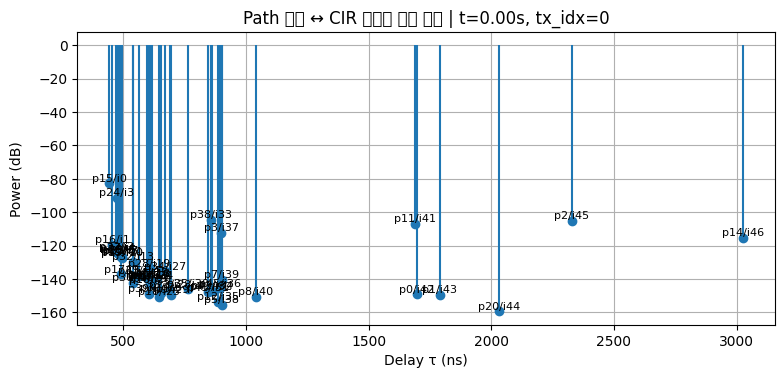

In [14]:
# 한글 주석: 현재 프레임/송신기 선택
frame_idx = 0
tx_idx = 0

t = float(time_steps[frame_idx])
pos = get_pos_at_time(t)

# 한글 주석: 위치/빔 방향 업데이트
rx.position = pos
for name in tx_names:
    scene.transmitters[name].look_at(pos)

# 한글 주석: 경로 계산 + CIR 계산
paths = solver(
    scene,
    max_depth=3,
    samples_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True
)

a, tau = paths.cir(out_type="tf", normalize_delays=False)

# a: (1, RxPol, Tx, TxPort, P, 1)
# tau: (1, Tx, P)
tau_tx = tau[0, tx_idx, :]  # (P,)

# 한글 주석: Rx편파/Tx포트 합산 PDP (경로축=P 유지)
pdp = tf.reduce_sum(tf.abs(a[0, :, tx_idx, :, :, 0])**2, axis=[0, 1])  # (P,)

# 한글 주석: padding/무효 경로 제거
valid = tf.math.is_finite(tau_tx) & (tau_tx >= 0)
idx_valid = tf.where(valid)[:, 0]   # 원본 path 인덱스

if tf.size(idx_valid) == 0:
    print("유효 경로가 없습니다.")
else:
    tau_v = tf.boolean_mask(tau_tx, valid)
    pdp_v = tf.boolean_mask(pdp, valid)

    # 한글 주석: 지연 기준 정렬 -> 그래프/표 순서를 CIR 임펄스 순서로 사용
    order = tf.argsort(tau_v)
    tau_s = tf.gather(tau_v, order).numpy() * 1e9
    pdp_s = tf.gather(pdp_v, order).numpy()
    pdp_db = 10*np.log10(pdp_s + 1e-30)

    # 한글 주석: path_idx(원본 경로 번호)와 임펄스 번호(정렬 후 순번) 매핑
    path_idx_sorted = tf.gather(idx_valid, order).numpy().astype(int)
    cir_impulse_idx = np.arange(len(path_idx_sorted), dtype=int)

    df_map = pd.DataFrame({
        "cir_impulse_idx": cir_impulse_idx,   # 정렬 후 임펄스 번호
        "path_idx": path_idx_sorted,          # 원본 경로 번호
        "tau_ns": tau_s,
        "pdp_db": pdp_db
    })

    display(df_map)

    # 한글 주석: CIR PDP 그래프 (라벨은 path_idx)
    plt.figure(figsize=(9, 3.8))
    plt.stem(df_map["tau_ns"].values, df_map["pdp_db"].values, basefmt=" ")
    for x, y, pid, cid in zip(df_map["tau_ns"].values,
                              df_map["pdp_db"].values,
                              df_map["path_idx"].values,
                              df_map["cir_impulse_idx"].values):
        plt.text(x, y, f"p{pid}/i{cid}", fontsize=8, ha="center", va="bottom")

    plt.xlabel("Delay τ (ns)")
    plt.ylabel("Power (dB)")
    plt.title(f"Path 번호 ↔ CIR 임펄스 번호 매핑 | t={t:.2f}s, tx_idx={tx_idx}")
    plt.grid(True)
    plt.show()